# Session 2 — Demo 1 — The five verbs of a table

**What this demo covers.** Everything you'll ever do to a *single* table is five verbs:

`select → filter → sort → derive → aggregate`

You already do all five in Excel (hide columns, dropdown filter, sort, formula column, pivot). Tonight: the same verbs, but repeatable and checkable. Verbs 1–4 are quick; you'll recognize them instantly. Verb 5, `groupby`, is the big one: we learn it on a table of **eight rows** first, then let it loose on 312 thousand. Then: the continuation of last week's detective story about hidden empty values.

At the very end there is an **⚡ Extras** section — pro shortcuts that do the same things in fewer keystrokes. It is *not required*: skip it today, come back when the five verbs feel boring.

**Data.** Same week of ALPHA warehouse picking events as Session 1 — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell.

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib

In [2]:
events = pd.read_parquet(DATA / "picking_events.parquet")
events.shape

(311543, 9)

## 1. Select — keep the columns you need

One pair of brackets with a column name gives you **one column**; you did this last week with `events["event_type"]`. Two pairs, brackets with a *list* of names inside, give you a smaller **table**:

In [3]:
# see the pandas table view below (the first 5 rows, from head)
events[["event_time", "event_type", "user_id"]].head()

,event_time,event_type,user_id
0,2026-03-02 11:51:59.142,StartTask,4500859
1,2026-03-02 11:53:33.779,ScanCell,4500859
2,2026-03-02 11:53:47.415,PickWrongItem,4500859
3,2026-03-02 11:53:56.955,PickCorrectItem,4500859
4,2026-03-02 11:54:40.688,ScanCell,4500859


In [4]:
# a single bracket gives a pandas Series (like an array), not a DataFrame
events['event_type'].head()

0          StartTask
1           ScanCell
2      PickWrongItem
3    PickCorrectItem
4           ScanCell
Name: event_type, dtype: str

In [5]:
events[['event_type']].head() # compare to the cell above

,event_type
0,StartTask
1,ScanCell
2,PickWrongItem
3,PickCorrectItem
4,ScanCell


*It helps to think of a `pd.DataFrame` as a dictionary: `{column_name: pd.Series}`.*

**WARNING**

Pandas has one trap here, especially in older versions: selecting columns with double brackets (`[[]]`) can give you unexpected results. Let's take a look.

In [6]:
events2 = events[['event_type', 'event_time']]

In pandas 3.0 and later, `events2` is an independent copy: change it and `events` stays exactly as it was.

Before pandas 3.0 you don't get that promise. Sometimes `events2` is a real copy, sometimes it is a window into `events`, and you cannot tell which one by looking at it. When it is a window, writing a new value into `events2` also changes `events`.

*Sometimes pandas warns you about this. Sometimes it doesn't.*

The fix is one word. Add `.copy()` after a double-bracket selection, like `events[['event_type', 'event_time']].copy()`, and the two tables stay independent.

So it matters which pandas you are on. Every library keeps its version number in `__version__`:

In [7]:
pd.__version__ # >=3.0

'3.0.3'

## 2. Filter — keep the rows that match

The Excel twin is the dropdown filter. In pandas it works in two steps, and the first step is worth seeing on its own.

**Step 1.** A comparison on a column produces a column of `True`/`False` — one verdict per row. It's called a **mask**:

In [8]:
is_wrong = (events["event_type"] == "PickWrongItem")
is_wrong.head()

0    False
1    False
2     True
3    False
4    False
Name: event_type, dtype: bool

**Step 2.** Put the mask inside the brackets, and pandas keeps exactly the rows where the mask says `True`:

In [9]:
wrong = events[is_wrong]
wrong.shape

(33317, 9)

In [10]:
wrong.head() # the same frame, but only the rows where event_type == "PickWrongItem"

,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason
2,2026-03-02 11:53:47.415,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM
21,2026-03-02 12:00:30.607,PickWrongItem,4500859,800000001,160985669.0,10000001.0,1.726267e+09,2.0,WRONG_ITEM
29,2026-03-02 12:07:58.819,PickWrongItem,4500859,800000002,55185393.0,10000002.0,1.944654e+09,5.0,WRONG_ITEM
50,2026-03-02 12:11:06.050,PickWrongItem,4500859,800000002,111723864.0,10000002.0,NaN,16.0,BARCODE_UNRESOLVED
51,2026-03-02 12:11:09.857,PickWrongItem,4500859,800000002,111723864.0,10000002.0,2.396092e+09,16.0,WRONG_ITEM


Usually you'll see both steps in one line. Same thing; read it inside-out: *events where event type equals PickWrongItem*:

```python
wrong = events[events["event_type"] == "PickWrongItem"]
```

You can combine several conditions in one filter, but each condition must be wrapped in parentheses `()` and joined with the bitwise operators:

- `&` = AND
- `|` = OR

And this is where the "new line = new condition" rule earns its keep. Compare two spellings of the *same* filter:

```python
# one long line: hard to read, and you cannot switch off a single condition to test it
wrong_in_full_cells = events[(events["event_type"] == "PickWrongItem") & (events["items_in_cell_quantity"] > 20) & (events["user_id"] == 6206221)]
```

***versus***

```python
# one condition per line: comment any line out, and the filter still runs
wrong_in_full_cells = events[
    (events["event_type"] == "PickWrongItem")
    & (events["items_in_cell_quantity"] > 20)
    & (events["user_id"] == 6206221)
]
```

*Let's try it.*

In [11]:
cell_id = 54400900

# one condition per line: comment any line out and the filter still runs
problem_cell_events = events[
    (events['cell_id'] == cell_id) # where the cell equals cell_id
    & (events['event_type'] == 'PickWrongItem') # where event is PickWrongItem
]
problem_cell_events.head()

,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason
2,2026-03-02 11:53:47.415,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM
4704,2026-03-02 15:10:16.854,PickWrongItem,2339064,800002817,54400900.0,10002487.0,NaN,129.0,BARCODE_UNRESOLVED
4706,2026-03-02 15:10:18.949,PickWrongItem,2339064,800002817,54400900.0,10002487.0,3.066219e+09,129.0,WRONG_ITEM
4711,2026-03-02 15:10:25.920,PickWrongItem,2339064,800002817,54400900.0,10002487.0,3.014677e+09,129.0,WRONG_ITEM
4713,2026-03-02 15:10:28.668,PickWrongItem,2339064,800002817,54400900.0,10002487.0,3.014677e+09,129.0,WRONG_ITEM


One more comparison you'll need constantly. `==` asks *"is it this one value?"*. **`.isin([...])`** asks *"is it any of these?"* — and gives back a mask, exactly like `==` does:

```python
events["event_type"].isin(["PickWrongItem", "PickCorrectItem"])   # True for either one
```

Below: both kinds of condition in one filter — an `.isin()` for the event type, and an `|` group for "this item **or** this cell". Note the inner brackets: `&` binds tighter than `|`, so the OR-group needs its own parentheses, or you get a different answer than the one you meant.

In [12]:
item_id = 3014676840

cell_or_item_events = events[
    # the event is either a wrong pick or a correct one...
    events['event_type'].isin(['PickWrongItem', 'PickCorrectItem'])
    # ...AND it touched either our item or our cell
    & (
        (events['item_id'] == item_id)
        | (events['cell_id'] == cell_id)
    )
]
cell_or_item_events.head()

,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason
2,2026-03-02 11:53:47.415,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM
3,2026-03-02 11:53:56.955,PickCorrectItem,4500859,800000001,54400900.0,10000001.0,1.679524e+09,135.0,NaN
634,2026-03-02 12:41:29.279,PickCorrectItem,8735343,800000014,54400900.0,10000277.0,1.679524e+09,134.0,NaN
638,2026-03-02 12:41:34.511,PickCorrectItem,8735343,800000014,54400900.0,10000277.0,1.679524e+09,133.0,NaN
3543,2026-03-02 14:28:00.096,PickCorrectItem,4500859,800002305,54400900.0,10001337.0,1.679524e+09,132.0,NaN


## 3. Sort — order by what matters

`sort_values` by a column; `ascending=False` puts the biggest on top. The fullest a cell has ever been at the moment it was scanned:

In [13]:
# a long chain is easier to read one step per line, like below:
# you can comment out any single line and find the problem faster
(
    events
    # 1. sort
    .sort_values("items_in_cell_quantity", ascending=False)
    # 2. keep only these columns
    [["event_time", "event_type", "cell_id", "items_in_cell_quantity"]]
    # 3. keep the top rows
    .head(3)
)

,event_time,event_type,cell_id,items_in_cell_quantity
173433,2026-03-06 13:46:27.028,PickWrongItem,106501276.0,332.0
97389,2026-03-04 14:58:37.974,PickCorrectItem,106501276.0,332.0
3198,2026-03-02 14:19:07.233,PickCorrectItem,106501276.0,332.0


You can also sort a `pd.Series`

In [14]:
events['event_time'].sort_values(ascending=False)

311542   2026-03-09 00:46:59.215
311541   2026-03-09 00:46:58.155
311540   2026-03-09 00:45:33.312
311539   2026-03-09 00:45:23.843
311538   2026-03-09 00:44:02.802
                   ...          
4        2026-03-02 11:54:40.688
3        2026-03-02 11:53:56.955
2        2026-03-02 11:53:47.415
1        2026-03-02 11:53:33.779
0        2026-03-02 11:51:59.142
Name: event_time, Length: 311543, dtype: datetime64[us]

## 4. Derive — add a column

The Excel twin is a formula column: new columns computed from old ones.

Assigning to a column name that doesn't exist yet **creates** it:

In [15]:
events['a_letter'] = 'a' 
events['10_number'] = 10 

events[['event_time', 'a_letter', '10_number']].head(3)

,event_time,a_letter,10_number
0,2026-03-02 11:51:59.142,a,10
1,2026-03-02 11:53:33.779,a,10
2,2026-03-02 11:53:47.415,a,10


Our richest raw material is `event_time`, and datetime columns carry a whole toolbox behind `.dt`. Type `events["event_time"].dt.` and hit Tab to see the menu (the same dot-and-abilities idea from Session 1).

Two of them do everything we need tonight: `.dt.date` gives the calendar day, and `.dt.hour` gives the hour of the day as a number from 0 to 23.

In [16]:
# events["event_time"].dt. # uncomment and press Tab to see what you can call after .dt

In [17]:
events["date"] = events["event_time"].dt.date
events["hour"] = events["event_time"].dt.hour
events[["event_time", "date", "hour", 'a_letter', '10_number']].head(3)

,event_time,date,hour,a_letter,10_number
0,2026-03-02 11:51:59.142,2026-03-02,11,a,10
1,2026-03-02 11:53:33.779,2026-03-02,11,a,10
2,2026-03-02 11:53:47.415,2026-03-02,11,a,10


A derived column can also be a mask. To combine two conditions, pandas uses `&` (AND), `|` (OR), `~` (NOT) — **with parentheses around each condition**. Without the parentheses Python crashes with a cryptic error; it's the classic first-week bug:

```python
events[events["hour"] >= 22 | events["hour"] < 6]   # 💥 crashes without parentheses
```

In [18]:
events["is_night"] = (events["hour"] >= 22) | (events["hour"] < 6)

# count how many rows carry each value
events["is_night"].value_counts(dropna=False)

is_night
False    180252
True     131291
Name: count, dtype: int64

In [19]:
# the same counts as a proportion
events["is_night"].value_counts(dropna=False, normalize=True)

is_night
False    0.578578
True     0.421422
Name: proportion, dtype: float64

**Shortcut.** For a True/False column with no empty values, the share of `True` is simply its mean:

In [20]:
events["is_night"].mean() * 100

np.float64(42.142176200396094)

42.1% of events happened at night

Now filtering on two conditions is just two masks glued with `&`. Here, wrong picks that happened at night:

In [21]:
wrong_at_night = events[
    (events["event_type"] == "PickWrongItem")
    # no brackets needed here — this column is already a True/False mask
    & events["is_night"]
]
print(f"wrong picks: {len(wrong):,}   of them at night: {len(wrong_at_night):,}")

wrong picks: 33,317   of them at night: 13,634


And `~` flips a mask — "everything that is NOT night":

In [22]:
day_events = events[~events["is_night"]]
print(f"night rows: {len(events) - len(day_events):,}   day rows: {len(day_events):,}")

night rows: 131,291   day rows: 180,252


## 5. Aggregate — from rows to answers

The Excel twin is the pivot table, and this verb answers most manager questions: *how many, how much — per worker, per day, per zone*. It deserves a slow start, so meet the smallest warehouse in the world — eight rows. (Build it straight from a dictionary of lists: each list is a column. It's the primer's "a dict describes one thing", scaled up.) One row has an empty `worker`, because the scanner lost the badge id. Keep an eye on that row:


> 🖼 **The picture for this section** is card 1 in `concept-cards.html`, in this same folder — open it next to the notebook if you'd rather see the piles than read about them.

In [23]:
mini = pd.DataFrame({
    "worker":  ["Anna", "Boris", "Anna", "Clara", "Boris", "Anna", None, "Clara"],
    "action":  ["pick", "pick", "pick", "scan", "pick", "scan", "pick", "pick"],
    "seconds": [5, 7, 6, 2, 9, 3, 4, 8],
    "has_error": [None, None, None, None, None, False, True, False]
})
mini

,worker,action,seconds,has_error
0,Anna,pick,5,None
1,Boris,pick,7,None
2,Anna,pick,6,None
3,Clara,scan,2,None
4,Boris,pick,9,None
5,Anna,scan,3,False
6,NaN,pick,4,True
7,Clara,pick,8,False


`groupby` works in three steps, **split → apply → combine**:

1. **split** the rows into piles by the key — one pile per worker: Anna's 3 rows, Boris's 2, Clara's 2;
2. **apply** one summary to each pile — count the rows, or average the seconds;
3. **combine** the answers into a new small table: one row per pile.

Count the rows in each pile with `.size()`:

In [24]:
mini.groupby("worker").size()

worker
Anna     3
Boris    2
Clara    2
dtype: int64

**Stop. Count with me.** The toy table has 8 rows; 3 + 2 + 2 = 7. One row is *gone* — the one with the empty `worker`. **`groupby` throws away rows whose key is empty.** No error, no warning. When the empty keys matter (ours will — wait for the detective), ask for them explicitly with `dropna=False`:

In [25]:
mini.groupby("worker", dropna=False).size()

worker
Anna     3
Boris    2
Clara    2
NaN      1
dtype: int64

### 🧪 The habit worth stealing from tonight

Look at what just happened. Nobody *told* us that `groupby` drops empty keys — we found out because we built eight rows we could count by eye, and the arithmetic didn't add up.

That move works for every function you will ever meet:

> **Not sure how something behaves? Build a tiny table where you already know the answer and look.**

Five rows are usually enough. Invent them, or copy a few rows out of the real data. It doesn't matter. Thirty seconds, and it never lies. It beats reading the documentation *and* asking an assistant, because it answers the question **for your data**. You'll see this used twice more tonight: on the four join types, and on `explode`.

`size` and `count` look alike, but they answer different questions. `size` counts **rows** — empty or not. `count` counts **values** — it skips the empty ones.

*Let's see it on the toy.*

In [26]:
mini.groupby("worker", dropna=False).size() # number of rows for every worker

worker
Anna     3
Boris    2
Clara    2
NaN      1
dtype: int64

In [27]:
mini.groupby("worker", dropna=False).count() # count per column, per worker

,action,seconds,has_error
worker,,,
Anna,3,3,1
Boris,2,2,0
Clara,2,2,1
NaN,1,1,1


For `action` and `seconds` the answer matches `size`. For `has_error` it doesn't — that column contains `None` values.

In [28]:
mini['has_error'].count(), mini['action'].count()

(np.int64(3), np.int64(8))

Rule of thumb: `size` counts rows, `count` counts values. Reach for `size` unless you specifically mean "non-empty".

In [29]:
# almost the same result as size, because `seconds` has no Nones
mini.groupby("worker", dropna=False)['seconds'].count()

worker
Anna     3
Boris    2
Clara    2
NaN      1
Name: seconds, dtype: int64

Counting is one possible summary of a pile; averaging is another. Name the column, then the summary:

In [30]:
mini.groupby("worker")["seconds"].mean()

worker
Anna     4.666667
Boris    8.000000
Clara    5.000000
Name: seconds, dtype: float64

What about many columns in a single groupby?

*A second form worth knowing: `.agg()` lets you name the output columns yourself — `new_column=(old_column, summary)`, one line per column you want.*

The summary is a short name in quotes. You already have `size`, `count`, `mean` and `sum`; two new ones appear below:

- `nunique` counts **distinct** values. How many *different* actions a worker did, not how many rows they have.
- `median` is the middle value after sorting. It gets a whole evening next week; for now just notice that it does not have to equal the mean.

In [31]:
(
    mini
    .groupby("worker")
    .agg(
        # new_column_name=(old_column, function)
        nunique_actions=("action", "nunique"),
        mean_seconds=("seconds", "mean"),
        median_seconds=("seconds", "median"),
        total_seconds=("seconds", "sum"),
    )
)

,nunique_actions,mean_seconds,median_seconds,total_seconds
worker,,,,
Anna,2,4.666667,5.0,14
Boris,1,8.000000,8.0,16
Clara,2,5.000000,5.0,10


Now the real warehouse. Top-10 pickers by successful picks: split 146 thousand successful picks into piles by worker, count each pile, sort, and take the head:

In [32]:
picks = events[events["event_type"] == "PickCorrectItem"]

(
    picks
    .groupby("user_id")   # one pile per worker
    .size()               # how many rows in each pile
    .sort_values(ascending=False)
    .head(10)
)

user_id
9051397    3097
6206221    2983
3145818    2772
9340963    2639
6962698    2626
9682063    2604
8502518    2592
5290120    2589
4013606    2563
4870681    2543
dtype: int64

In [33]:
# same answer, spelled with count() on a column that has no empty values
(
    picks
    .groupby("user_id")["event_time"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

user_id
9051397    3097
6206221    2983
3145818    2772
9340963    2639
6962698    2626
9682063    2604
8502518    2592
5290120    2589
4013606    2563
4870681    2543
Name: event_time, dtype: int64

Remember last week's promise, "a simple groupby, we'll talk about it next week"? Here it is. Events per day is *exactly* this verb, splitting by the derived `date` column. (And `value_counts` from Session 1? It's a shortcut for `groupby(...).size().sort_values(ascending=False)`, one special case of the verb you now own.)

In [34]:
events.groupby("date").size()

date
2026-03-02    25857
2026-03-03    44066
2026-03-04    43238
2026-03-05    46289
2026-03-06    46210
2026-03-07    52513
2026-03-08    52763
2026-03-09      607
dtype: int64

## 6. The detective, continued

Last week the float dtypes told us: *these columns have holes*. Time to map the holes — where exactly, and is there a pattern?

Two small tools first. `.isna()` asks every value "are you empty?" and returns a mask; `.notna()` is its opposite. And a mask has a lovely property: `True` counts as 1 and `False` as 0, so **the mean of a mask is a share**:

In [35]:
events.dtypes

event_time                datetime64[us]
event_type                           str
user_id                            int64
task_id                            int64
cell_id                          float64
boxing_id                        float64
item_id                          float64
items_in_cell_quantity           float64
reason                               str
a_letter                             str
10_number                          int64
date                              object
hour                               int32
is_night                            bool
dtype: object

In [36]:
share_of_empty = (
    events["item_id"]
    .isna()
    .mean()
)
share_of_empty

np.float64(0.44730261954208567)

In [37]:
print(f"share of rows with empty item_id: {share_of_empty:.3f}")

share of rows with empty item_id: 0.447


One number for the whole table is crude. The interesting question is per **event type**, and that is a groupby: build a True/False table of "is it empty?", attach the event type (derive!), split-apply-combine with `.mean()`:

In [38]:
key_cols = ["cell_id", "item_id", "boxing_id", "items_in_cell_quantity", "reason"]
holes = events[['event_type'] + key_cols].copy() # just an old habit from pandas < 3.0
holes[key_cols] = holes[key_cols].isna() # a True/False table, same rows as events
holes.head(3)

,event_type,cell_id,item_id,boxing_id,items_in_cell_quantity,reason
0,StartTask,True,True,True,True,True
1,ScanCell,False,True,True,False,True
2,PickWrongItem,False,False,False,False,False


Now let's compute the share of empty values per column, for each event type.

`.round(2)` at the end keeps two digits after the point. Without it every cell prints a long decimal and the pattern is much harder to see.

In [39]:
holes.groupby("event_type").mean().round(2)

,cell_id,item_id,boxing_id,items_in_cell_quantity,reason
event_type,,,,,
DropBoxing,0.0,1.00,0.0,1.0,1.0
FinishTask,1.0,1.00,1.0,1.0,1.0
MarkDefectItem,0.0,0.00,1.0,1.0,1.0
PickCorrectItem,0.0,0.00,0.0,0.0,1.0
PickWrongItem,0.0,0.22,0.0,0.0,0.0
ScanCell,0.0,1.00,1.0,0.0,1.0
SkipItem,0.0,0.00,1.0,1.0,1.0
StartTask,1.0,1.00,1.0,1.0,1.0


Read it **through the process**: `StartTask`/`FinishTask` are task-level actions — of course they carry no cell and no item. Structural, boring, fine.

Two cells of this table are *not* boring, and they hang together: **~22% of wrong-pick scans have no `item_id`** — and `reason` is empty everywhere *except* wrong picks. A column that lives on exactly one event type is usually there to explain it. So ask it: filter to the rows where `reason` is present (`.notna()`), and count the values; `normalize=True` turns counts into shares:

In [40]:
(
    events
    [events["reason"].notna()]
    ["reason"]
    .value_counts(normalize=True)
    .round(2)
)

reason
WRONG_ITEM            0.78
BARCODE_UNRESOLVED    0.22
Name: proportion, dtype: float64

The data answered its own mystery: on most wrong scans the terminal logs the neighbour item it rejected (`WRONG_ITEM`), but in ~22% of cases it **couldn't resolve the barcode at all** (`BARCODE_UNRESOLVED`) — hence the missing `item_id`. 

Note the move: *before asking a human, check whether a column already answers the question.*

And here is the toy-table warning striking in real life. Count wrong picks *by item*, then add the piles back up:

In [41]:
by_item = wrong.groupby("item_id").size()
by_item.head()

item_id
100232609.0    1
100242557.0    1
100298429.0    2
100739340.0    1
100893489.0    3
dtype: int64

In [42]:
print(
      f"wrong picks: {len(wrong):,}\n"
      f"sum over all items: {by_item.sum():,}\n"
      f"lost by groupby: {len(wrong) - by_item.sum():,}"
)

wrong picks: 33,317
sum over all items: 26,112
lost by groupby: 7,205


A fifth of the errors fell straight out of the count: the unresolved-barcode rows have an empty key, and `groupby` dropped them exactly as it dropped the badge-less toy row. Anyone reporting "errors by item" without knowing this under-counts by 22% and never notices. (`dropna=False` would keep them as one extra `NaN` pile.)

Second find: do all tasks finish? `.isin()` from section 2 is exactly the tool: it asks every value "are you in that collection?" and hands back a mask. With `~` in front it reads "started tasks that are NOT among the finished":

In [43]:
started = events[events["event_type"] == "StartTask"]["task_id"]
finished = events[events["event_type"] == "FinishTask"]["task_id"]
never_finished = started[~started.isin(finished)]
print(
      f"tasks started: {len(started):,}   never finished: "
      f"{len(never_finished):,} ({len(never_finished) / len(started):.1%})"
)

tasks started: 4,237   never finished: 160 (3.8%)


About 4% of tasks never see a `FinishTask`. Interruptions are part of warehouse life, but if you ever average "time per task", these rows have no finish time at all, so your average describes only the tasks that finished. Nothing on screen says so. Noted.

Third find: does the data *breathe*? Find the most-picked (cell, item) pair of the week: group by **two** keys (pass a list), count, sort:

In [44]:
pair_counts = (
    picks
    .groupby(["cell_id", "item_id"])
    .size()
    .sort_values(ascending=False)
)
pair_counts.head(3)

cell_id      item_id     
125062878.0  2.976047e+09    563
74281475.0   1.221795e+09    539
73693598.0   3.269107e+09    444
dtype: int64

The pile labels live in `.index`, and `[0]` takes the first one: our champion pair. Filter down to it (two conditions, verb 2) and watch the quantity in that cell through the week:

In [45]:
top_cell, top_item = pair_counts.index[0]
pair_counts.index[0] # (cell_id, item_id)

(np.float64(125062878.0), np.float64(2976046529.0))

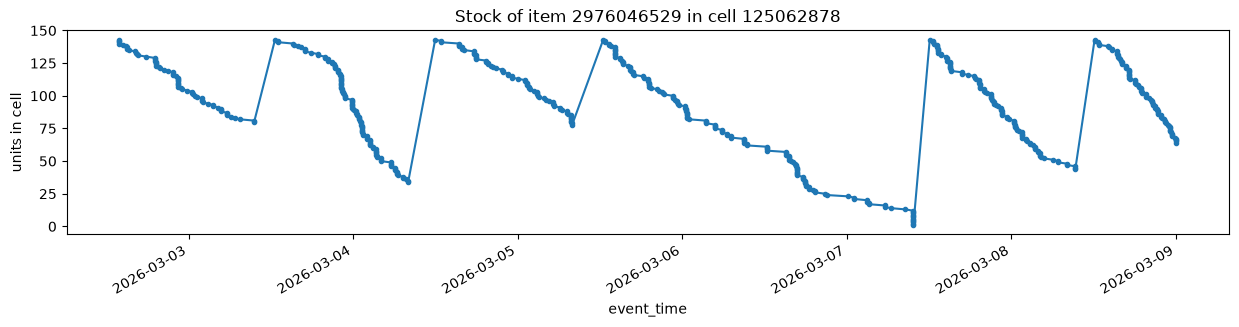

In [46]:
# take all PickCorrectItem events for this cell_id and item_id
one_slot = picks[
    (picks["cell_id"] == top_cell)
    & (picks["item_id"] == top_item)
]

ax = one_slot.plot(
    x="event_time",
    y="items_in_cell_quantity",
    marker=".",
    figsize=(15, 3),
    legend=False,
    title=f"Stock of item {int(top_item)} in cell {int(top_cell)}"
)
ax.set_ylabel("units in cell")
plt.show()

It falls while pickers take from it — and jumps back up between days: the overnight **replenishment crew**. Nobody told us the warehouse restocks at night; the data did.

## Try it yourself

1. Which **hour of day** has the most *wrong* picks? Is it the busiest hour overall (you saw that chart last week)? *(filter → groupby by `hour` → sort)*
2. Which picker works the most **night** events? *(the `is_night` column is ready)*
3. What share of all events are `ScanCell` events? *(one mask, one mean)*

In [47]:
# your turn


---

## ⚡ Extras — power tools, not required

Everything below redoes results from above in fewer keystrokes. Nothing new conceptually; these are shortcuts you'll reach for after a few weeks of practice. Skip freely, return later.

**`unstack` — turn a two-key groupby into a grid.** Group by two keys and you get one row per (day, type) pair — long and hard to scan. `unstack` pivots the second key into columns (`fill_value=0` fills the gaps): the day × type matrix a manager actually asks for.

In [48]:
# Try to do it step by step
(
    events
    .groupby(["date", "event_type"])
    .size()
    .unstack(fill_value=0)
)

event_type,DropBoxing,FinishTask,MarkDefectItem,PickCorrectItem,PickWrongItem,ScanCell,SkipItem,StartTask
date,,,,,,,,
2026-03-02,577,317,1,12120,3048,9438,15,341
2026-03-03,1005,569,10,20365,5169,16333,22,593
2026-03-04,968,546,5,20479,4455,16199,20,566
2026-03-05,1063,619,4,21618,4920,17408,20,637
2026-03-06,1071,616,0,21898,4572,17401,10,642
2026-03-07,1191,702,17,24612,5364,19875,17,735
2026-03-08,1207,695,10,24516,5738,19854,20,723
2026-03-09,20,13,0,296,51,225,2,0


**`agg` + `lambda` — the null map as a one-liner.** `lambda s: ...` is a tiny unnamed function written inline (the primer's `def`, squeezed into one expression); `.agg(f)` applies your function to every column of every pile:

In [49]:
(
    events
    .groupby("event_type")
    [key_cols]
    .agg(lambda s: s.isna().mean().round(2))
)

,cell_id,item_id,boxing_id,items_in_cell_quantity,reason
event_type,,,,,
DropBoxing,0.0,1.00,0.0,1.0,1.0
FinishTask,1.0,1.00,1.0,1.0,1.0
MarkDefectItem,0.0,0.00,1.0,1.0,1.0
PickCorrectItem,0.0,0.00,0.0,0.0,1.0
PickWrongItem,0.0,0.22,0.0,0.0,0.0
ScanCell,0.0,1.00,1.0,0.0,1.0
SkipItem,0.0,0.00,1.0,1.0,1.0
StartTask,1.0,1.00,1.0,1.0,1.0


**`idxmax` — "which label holds the maximum?"** in one step, instead of sort-then-take-first:

In [50]:
picks.groupby(["cell_id", "item_id"]).size().idxmax()

(np.float64(125062878.0), np.float64(2976046529.0))

**`set` — Python's bag of unique values.** Subtracting one set from another gives "in the first but not the second" — the unfinished tasks again:

In [51]:
started_set = set(events[events["event_type"] == "StartTask"]["task_id"])
finished_set = set(events[events["event_type"] == "FinishTask"]["task_id"])
print(f"never finished: {len(started_set - finished_set):,}")

never finished: 160


## Recap

- Five verbs: `select, filter, sort, derive, aggregate`. That is the whole of single-table work.
- A filter is a **mask**, a True/False column, put inside brackets; combine masks with `&` / `|` / `~` and **parentheses around each condition**.
- `groupby` = split → apply → combine; `value_counts` is its shortcut.
- **`groupby` drops rows with an empty key, with no error and no warning** — on our data that's a fifth of all wrong picks; `dropna=False` keeps them.
- The mean of a mask is a share: `.isna().mean()` = "what fraction is empty".
- Empty values have a *geography*: structural holes are fine, the rest are findings — and sometimes a neighbouring column (`reason`) already explains them.
- ~4% of tasks never finish; stock falls by day and refills overnight — the table keeps telling the process story.

- **When in doubt, build a toy table.** Eight invented rows told us more about `groupby` than any paragraph could — and the same trick works for every function you'll meet.